# **Statistics Lecture 1 : exercises notebook**

The _Practical Statistics_ course has two components: the lectures, and practical exercises using jupyter notebooks. This is the companion notebook to lecture 1, covering the following topics:
1. PDF means, variance and covariance
2. Quantiles of the normal distribution
3. The Poisson distribution and the central limit theorem
4. Histograms and $\chi^2$

It presents some explanations followed by exercises (highlighted in $\mathbf{\color{red}{\text{red}}}$)

## 1. Basics

The notebooks accompanying the lectures will make use of the `numpy`/`scipy`/`matplotlib` stack. It's also possible to implement these examples with other tools such as `root`, for those who are more familiar with it and have it installed. We'll go with `numpy`/`scipy`/`matplotlib` which has the advantage of being more widely available, and easy to run in tools such as `binder`, but feel free to use other implementations if you like.

To start with, we need to import the relevant python packages:

In [1]:
import numpy as np  # handles most of the numerical work
import scipy.stats  # implements statistical tools (PDFs, etc)
from matplotlib import pyplot as plt # for plotting

numpy handles most of the underlying work. In particular operations will usually be performed on numpy arrays -- arrays of floats similar to python lists.
For instance we can generate some events as follows:

In [2]:
yvals = np.random.normal(3.0, 1.0, 10) # generate 10 events from a Gaussian(mean=3, sigma=1) distribution
print(yvals)

[2.01632042 3.00306108 2.70658604 3.79653694 2.77901807 4.18261419
 2.83665796 1.87442685 4.51773696 2.51853197]


The `scipy` package has some useful features like fully-featured PDF implementations, and `matplotlib` will be used for inline plots. As an example of how things work, we can draw a few Gaussian curves: 

In [3]:
xvals = np.linspace(-5,5,100) # an array of 100 points between -5 and 5 which will be used for plotting
means = [0.0, 1.0, -2.0]   # a few mean values to plot

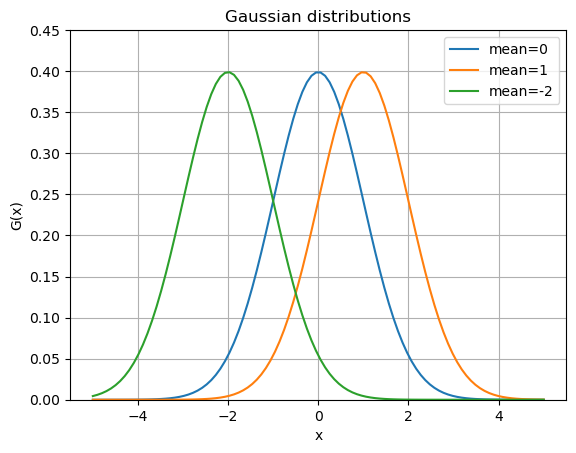

In [4]:
# Note that plt.plot takes 2 arrays, one array of x values and an array of y values.
# norm.pdf is a scalar function, which takes as input a single x value and returns the value of
# the normal PDF at x.
# In python, the construct [ f(xval) for xval in xvals ] can be used to build the list of
# all the f(xval) values, using only 1 line of code

for mean in means:
    yvals = [ scipy.stats.norm.pdf(xval, loc=mean, scale=1) for xval in xvals ] # compute the y-values for each x
    plt.plot(xvals, yvals, label='mean=%g' % mean) # draw the plots

plt.ylim(0,0.45)   # adjust the y range
plt.grid(True)     # draw grid lines on the plot
plt.xlabel('x')
plt.ylabel('G(x)')
plt.title('Gaussian distributions')
plt.legend();

Now repeat with different widths, and a mean of 0 :

In [5]:
sigmas = [1.0, 2.0, 3.0]   # a few sigma values to plot

$\mathbf{\color{red}{\rightarrow\text{Now draw the corresponding plots by completing the code below}}}$

In [6]:
for sigma in sigmas:
    pass # replace with real code

One can also generate random datasets and plot the result:

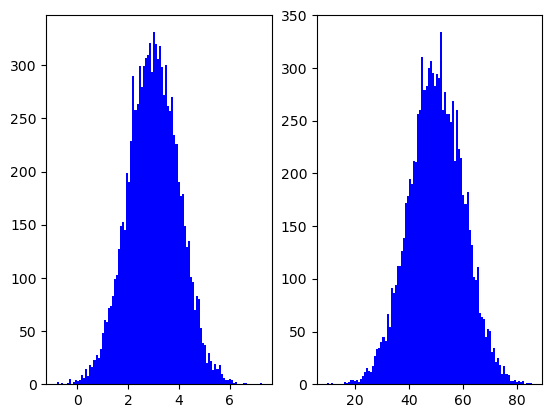

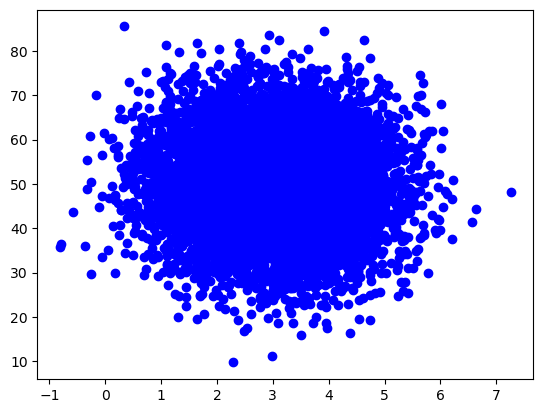

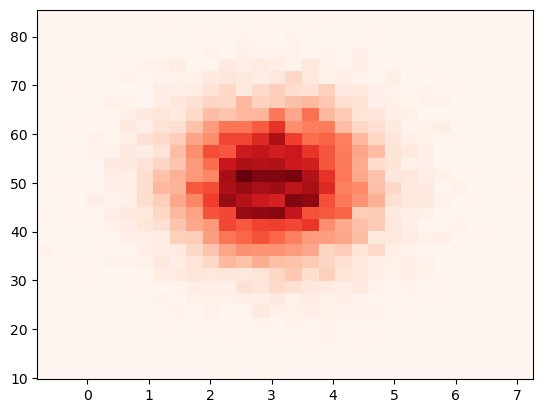

In [7]:
# generate two random variables
xvals = np.random.normal(3.0, 1.0, 10000)
yvals = np.random.normal(50.0, 10.0, 10000)

plt.subplot(121)
plt.hist(xvals, bins=100, color='b')
plt.subplot(122)
plt.hist(yvals, bins=100, color='b')
plt.figure()
plt.scatter(xvals,yvals, color='b')
plt.figure()
plt.hist2d(xvals, yvals, (30, 30), cmap='Reds');

Now we can compute some sample means, variances and covariances:

In [8]:
mean_x = np.sum(xvals)/len(xvals)
mean_y = np.sum(yvals)/len(xvals)
print('sample means:', mean_x, mean_y)

sample means: 3.003463521876803 50.06876163224102


$\mathbf{\color{red}{\rightarrow\text{Now compute the variance, covariance and correlation coefficient of x and y in the same way using np.sum()}}}$

In [9]:
var_x = 999 # replace with real code
var_y = 999 # replace with real code
print('sample variances:', var_x, var_y)
print('sample RMSs:', np.sqrt(var_x), np.sqrt(var_y))
cov_xy = 999 # replace with real code
cor_xy = 999 # replace with real code
print('sample covariance and correlation coefficient:', cov_xy, cor_xy)

sample variances: 999 999
sample RMSs: 31.606961258558215 31.606961258558215
sample covariance and correlation coefficient: 999 999


This can also be done more simply using numpy internal functions:

In [10]:
print('sample means:', np.mean(xvals), np.mean(yvals))
print('sample variances:', np.var(xvals, ddof=1), np.var(yvals, ddof=1))
print('sample covariance and correlation coefficient:', np.cov(xvals, yvals, ddof=1)[0,1], np.corrcoef(xvals,yvals)[0,1])


sample means: 3.003463521876803 50.06876163224102
sample variances: 0.9927026264058041 98.86144318485181
sample covariance and correlation coefficient: -0.1029579783659801 -0.010392904771075942


Note that the covariance and correlations coefficient should really be zero, the non-zero value here is due to fluctuations. For a case with real correlation, one can do

In [11]:
zvals = 5*xvals + yvals

$\mathbf{\color{red}{\rightarrow\text{Now plot z vs. x and compute the covariance and correlation coefficient of x and z}}}$

In [12]:
pass # your code here

## 2. Gaussian quantiles

The *quantiles* of a PDF are the fraction of its integral within a given range of its variable. The quantiles of the normal distribution $N(x) = G(x; x_0=0,\sigma=1)$ play an important role since they are used to define some important quantities later ($1\sigma$ and $1\sigma$ errors, $5\sigma$ discovery, etc.). 

One defines the cumulative distribution function of normal as $\Phi(x) = \int\limits_{-\infty}^x N(t) dt$, and a two-sided version can also be defined as $\Phi(x, y) = \int\limits_x^y N(t) dt$

They are easy to compute using the scipy tools:

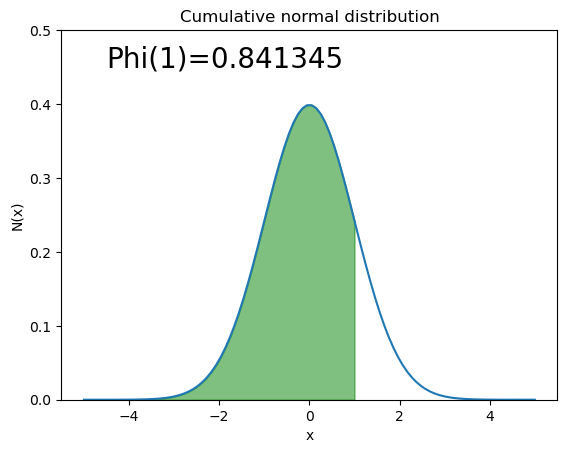

In [13]:
# Draw a normal distribution as before
xvals = np.linspace(-5,5,100)
yvals = [ scipy.stats.norm.pdf(xval) for xval in xvals ]
fig = plt.figure()
plt.plot(xvals, yvals)
plt.ylim(0,0.5)
plt.title("Cumulative normal distribution")
plt.xlabel('x')
plt.ylabel('N(x)')

# Now fill in part of the distribution and print the integral
up = 1
shaded_xvals = np.linspace(-5,up,100)
shaded_yvals = [ scipy.stats.norm.pdf(xval) for xval in shaded_xvals ]
plt.fill_between(shaded_xvals, shaded_yvals, alpha=0.5, color='g')
plt.text(-4.5, 0.45, 'Phi(%g)=%g' % (up, scipy.stats.norm.cdf(up)), fontsize=20);

This form is normally referred to as a *one-sided* quantile. Two-sided quantiles apply the boundary on both sides:

$\mathbf{\color{red}{\rightarrow\text{Now draw and compute the *two-sided* 1-sigma quantile (from -1 to +1) [Feel free to copy-and-paste the code above!]}}}$ 

In [14]:
pass # your code here
shaded_xvals = np.linspace(-up,up,100)
pass # more code here

Now let's plot some quantiles for different values of the bounds. As we'll see, the tail integrals (a.k.a the *survival function*, corresponding to the unshaded areas above) are also useful, so compute all of the following:

In [15]:
bounds = [0, 1, 2, 3, 4, 5]
one_sided = [ scipy.stats.norm.cdf(up) for up in bounds ]
one_sided_tail = [ scipy.stats.norm.sf(up) for up in bounds ]

$\mathbf{\color{red}{\rightarrow\text{Compute the two-sided integrals for each value of "bounds"}}}$ 

In [16]:
two_sided = [ -999 for up in bounds] # replace with real code
two_sided_tail = [ -999 for up in bounds ] # replace with real code

# Pretty-print the result
import pandas as pd
import jinja2
labels = [ 'Bound', '1-sided', '1-tail', '2-sided', '2-tail' ]
data = np.array([ bounds, one_sided, one_sided_tail, two_sided, two_sided_tail ]).T
pd.DataFrame(data, columns=labels)

,Bound,1-sided,1-tail,2-sided,2-tail
0,0.0,0.500000,5.000000e-01,-999.0,-999.0
1,1.0,0.841345,1.586553e-01,-999.0,-999.0
2,2.0,0.977250,2.275013e-02,-999.0,-999.0
3,3.0,0.998650,1.349898e-03,-999.0,-999.0
4,4.0,0.999968,3.167124e-05,-999.0,-999.0
5,5.0,1.000000,2.866516e-07,-999.0,-999.0


## 3. Poisson distributions and the Central-limit theorem

First let's get acquainted with Poisson distributions. As explained in the lecture, they are critical to describe counting processes, and become progressively more Gaussian with increasing event rates, so we can check a few rate hypotheses:

,Rate,Mean,Variance
0,0.1,0.1,0.1
1,1.0,1.0,1.0
2,3.0,3.0,3.0
3,10.0,10.0,10.0


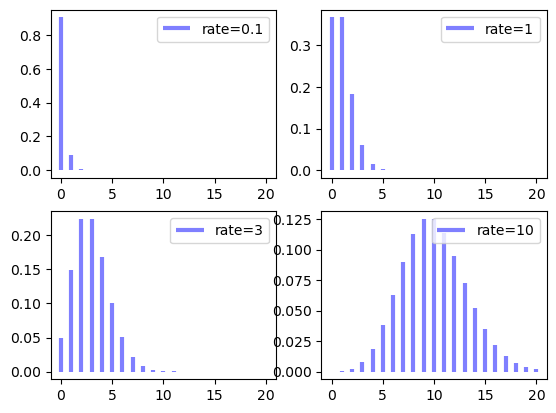

In [17]:
xvals = np.linspace(0, 20, 21)
rates = [ 0.1, 1, 3, 10 ]

for i, rate in enumerate(rates) :
  plt.subplot(221 + i)
  plt.vlines(xvals, 0, scipy.stats.poisson.pmf(xvals, rate), colors='b', lw=3, alpha=0.5, label='rate=%g' % rate)
  plt.legend()

means     = [ scipy.stats.poisson.stats(mu=rate, moments='m') for rate in rates ]
variances = [  scipy.stats.poisson.stats(mu=rate, moments='v')  for rate in rates ]
pd.DataFrame(np.array([ rates, means, variances]).T, columns=[ 'Rate', 'Mean', 'Variance' ])

In [18]:
nexp = 10000
nterms = [ 1, 2, 3, 5, 10, 100 ]

$\mathbf{\color{red}{\rightarrow\text{Exercise: check the central limit theorem by drawing Poisson events:}}}$
- For $nterms=1$, draw $nexp=10000$ $Poisson(1)$ events (`n = np.random.poisson(1)`) and histogram them
- For $nterms=2$, draw pairs of $Poisson(1)$ events and histogram their averages
- Repeat for the $nterms$ values provided above, to get increasingly Gaussian distributions

In [19]:
for nterm in nterms :
    pass # replace with real code

As expected, the distribution becomes more Gaussian as we increase the number of terms, with a variance that grows as $\sqrt n$.

## 4. Histograms and the $\chi^2$ test


We consider a 20-bin histogram of data over $[0,1]$, which we assume is coming from a linear distribution, $f(x) \propto (1 - x/2)$. We also assume that we have a histogram of data, and would like to decide whether the data is compatible with the assumed linear distribution. 

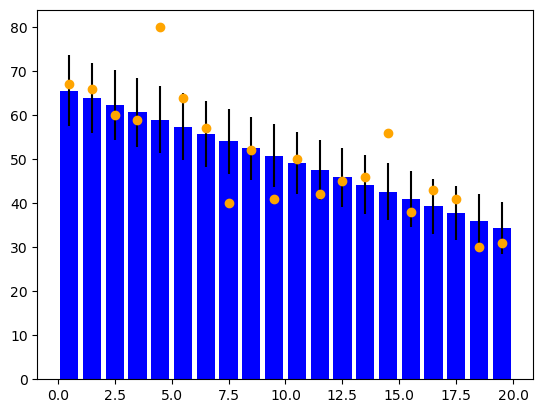

In [20]:
nbins = 20
nevts = 1000
np.random.seed(0)
xvals = np.linspace(0.5, nbins - 0.5, nbins)
expected_yields = np.array([ (1 - i/2/nbins) for i in range(0, nbins) ])
expected_yields *= nevts/np.sum(expected_yields)
dataset = [ np.random.poisson(y) for y in expected_yields ]
plt.figure()
plt.bar(xvals, expected_yields, yerr=np.sqrt(expected_yields), color='b')
plt.scatter(xvals, dataset, color='orange', zorder=10)

$\mathbf{\color{red}{\rightarrow\text{Compute chi2 values}}}$
- Compute the chi2 values between the dataset and the expected yields as the sum of `(d - y)/np.sqrt(y)`
- Compute the chi2 p-value using `scipy.stats.chi2.sf(chi2, nbins)`
- Compute the significance for the pvalue using `scipy.stats.norm.isf(pvalue)`

In [21]:
chi2 = sum( [ 999 for d,y in zip(dataset, expected_yields) ]) # replace 999 by real code
pvalue = 999   # replace 999 by real code
signif = 999   # replace 999 by real code
print('chi2:', chi2)
print('p(chi2):', pvalue)
print('signif(chi2):', signif)

chi2: 19980
p(chi2): 999
signif(chi2): 999


The compatibility between the generated dataset the true distribution may be larger or smaller depending on the random fluctuations that were generated, but generally the agreement should be quite good.

One can check that the distribution is doing what it is expected by generating datasets:

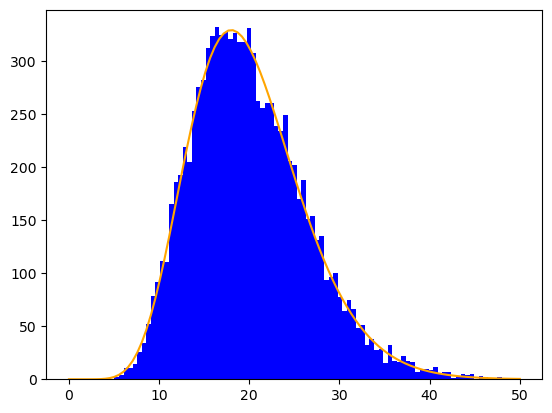

In [22]:
ndata = 10000
all_data = [ [ np.random.poisson(y) for y in expected_yields ] for i in range(0, ndata) ]
all_chi2 = [ sum( [ ((d-y)/np.sqrt(y))**2 for d,y in zip(data, expected_yields) ]) for data in all_data ]
bins = np.linspace(0,50,100)
plt.hist(all_chi2, bins=bins, color='b');
plt.plot(bins, scipy.stats.chi2.pdf(bins, 20)*ndata/2, color='orange')

The p-value we have computed above is the tail integral in the distribution above, and we see that it agrees quite well with the generated datasets.

If we now consider a prediction with the opposite slope, this will be generally much worse:

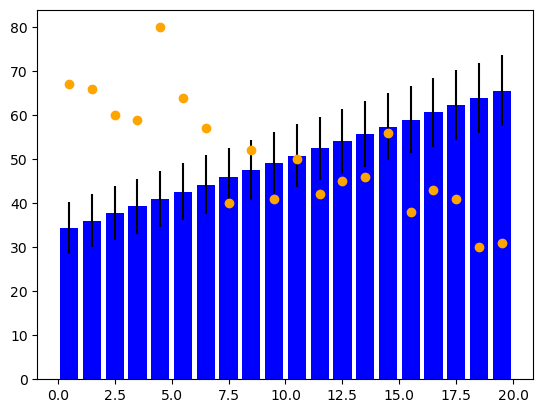

In [23]:
new_dataset = np.flip(expected_yields)
plt.figure()
plt.bar(xvals, new_dataset, yerr=np.sqrt(new_dataset), color='b')
plt.scatter(xvals, dataset, color='orange', zorder=10)

$\mathbf{\color{red}{\rightarrow\text{Recompute the chi2, chi2 pvalue, and chi2 signifiance for the new dataset}}}$

You should find a very large $\chi^2$, a small $p$-value and a large significance, all indicative of a significant disagreement between the dataset and the prediction

In [24]:
pass # replace with real code

Finally, one can repeat the whole study with a lower number of events per dataset, e.g. 10 instead of 1000. In this regime, the Poisson distributions in each bin are not Gaussian enough, and the computed $\chi^2$ does not in fact follow a $\chi^2$ distribution. In this case, one needs to move away from the $\chi^2$ formula and use a statistical model than accounts for Poisson effects.

## 5. Maximum likelihood for a single Poisson

To illustrate Maximum Likelihood in practice, we consider an example with binned data. We take a simple model with signal and background:

In [25]:
s = 2
b = 1

# Now generate some random data for the s+b hypothesis
np.random.seed(1) # Set the random seed to make sure we generate the same data every time
n = np.random.poisson(s + b)

print(n)

2


The situation above shows a rather standard case where we count events with coming from 2 sources: signal and background. Since we are in a counting situation, the observed event count $n$ is described by a Poisson distribution.

We now want to estimate the best-fit signal in this (pseudo) experiment. We know the answer already:

In [26]:
best_s = n - b
print("naïve best-fit = ", best_s)

naïve best-fit =  1


Note that the best-fit value is lower than the true value $s = 2$ that was used to generate, since we had a slight negative fluctuation when generating the data.

However the goal here is to exercise the maximum-likelihood (ML) estimation techniques that will be useful in more complex examples later. So we are going to compute the ML estimate $\hat{s}$ of $s$, which (hopefully!) will match what we have just above.

We will define the likelihood $L(s)$, and then move to the quantity $\lambda = -2 \log L(s)$ that will be more useful later.
We can use either, since maximizing $L(s)$ is equivalent to minimizing $\lambda(s)$, and the ML estimate $\hat{s}$ at the maximum/minimum is the same either way,

Let's now compute the ML estimate (best fit) $\hat{s}$ using $\lambda(s)$ :

In [27]:
# Define a scan over s values:
s_values = np.arange(-0.5, 3.5, 0.1)

$\mathbf{\color{red}{\rightarrow\text{Compute }\lambda\text{ for each value of }s \text{, plot the result and find the best-fit value among the values tested.}}}$
<span style="color:red">Note that the likelihood $L(s)$ is just a Poisson PDF, and recall that in scipy you evaluate a Poisson PDF using ```scipy.stats.poisson.pmf(nobs, mean)``` where ```mean``` is the Poisson parameters (i.e. the mean and variance of the distribution) and ```nobs``` is the observed number of events.</span>

$\mathbf{\color{green}{Answer}}$ : 

hat{s}, ML = (np.float64(-0.5), np.int64(-999))


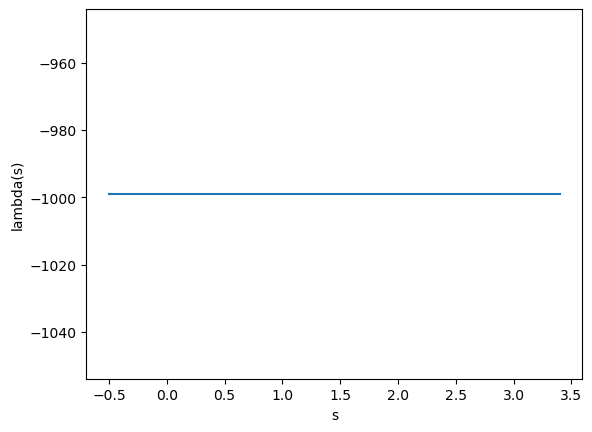

In [28]:
def L(s, nobs) :
    return -999 # change this to python code that will compute the Poisson likelihood (or PDF) for nobs and mean=s+b

def lambda_s(s, nobs) :
    return -999 # change this to python code that will compute -2 log L

lambda_values = np.array([ lambda_s(s_value, n) for s_value in s_values ]) # compute the likelihood (the Poisson PDF for each s)

# Plot the result
plt.plot(s_values, lambda_values)
plt.xlabel('s')
plt.ylabel('lambda(s)')

# Find the maximum likelihood value in the list : merge the 2 lists and find the max based on the L value
from operator import itemgetter
print('hat{s}, ML =', min( [ (s,l) for s,l in zip(s_values, lambda_values) ], key=itemgetter(1)))

If all goes well, you should find a best-fit $\hat{s}$ of about 1.

You also get the value of $\lambda(\hat{s})$, but this is not very interesting. Since $L(s)$ was defined only up to a multiplicative factor, $\lambda(s)$ is defined up to an additive constant, so the value $\lambda(\hat{s})$ at the minimum isn't meaningful. On the other hand, the difference between values of $\lambda(s)$ at different $s$ is meaningful, and will be used later in hypothesis testing.

Of course the $\hat{s}$ value we got was a bit imprecise due to the step size of 0.1 in the scan, but we can do better:

In [29]:
from scipy.optimize import minimize_scalar
# Compute the value at minimum (.x selects the position of the minimum, .fun would return the function value)
s_hat = minimize_scalar(lambda s : lambda_s(s, n), bounds=(0, 100)).x
print('exact hat{s}:', s_hat)

exact hat{s}: 99.9999921581193


You should find a best-fit value of exactly $\hat{s} = 1$, which is the correct value as we know since the beginning.

## 6. Maximum likelihood for binned data

We now a consider a more realistic example with binned data. Since there are multiple bins (here 10), there's no way to guess the answer and we'll really need the ML to get the best-fit signal. We again take a simple model with both a signal and a background component:

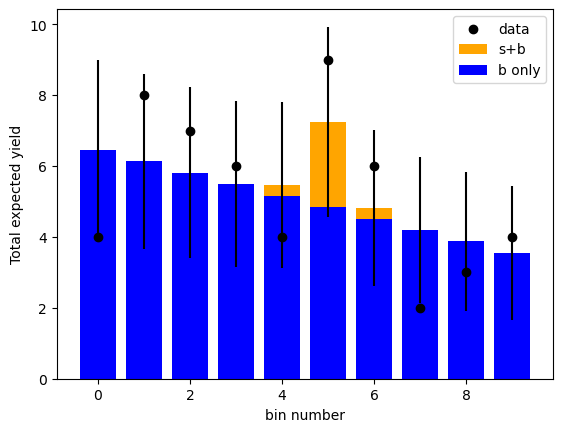

In [30]:
# Define the binning
nbins = 10
x = np.linspace(0, nbins - 1, nbins)

# The background follows a linear shape
b_yields = np.array([ (1 - i/2/nbins) for i in range(0, nbins) ])
b_fracs = b_yields/np.sum(b_yields)

# The signal shape is a peak
s_fracs = np.zeros(nbins)
s_fracs[4:7] = [ 0.1, 0.8, 0.1 ]

# Define the signal and background
s = 3
b = 50
s_and_b = s*s_fracs + b*b_fracs
b_only = b*b_fracs

# Now generate some data for the s+b model
np.random.seed(14) # Set the random seed to make sure we generate the same data every time
data = [ np.random.poisson(s*s_frac + b*b_frac) for s_frac, b_frac in zip(s_fracs, b_fracs) ]

# Make a plot of the result
plt.bar(x, s_and_b, color='orange', yerr=np.sqrt(s_and_b), label='s+b')
plt.bar(x, b_only, color='b', label='b only')
plt.scatter(x, data, zorder=10, color='k', label='data')
plt.xlabel('bin number')
plt.ylabel('Total expected yield')
plt.legend();

The plot above shows the typical case of a binned analysis: we have 2 *templates*, i.e. reference shapes for signal and background. These are given by bin fractions $f_{S,i}$ and $f_{B,i}$ which are normalized to 1. They are then scaled by the yields $s$ and $b$.

The ML estimate $\hat{s}$ corresponds to the "best fit" of the templates to the data, so one can more or less read it off the plot: naively, one expects something a bit larger than the $s=3$ value that is shown in the plot, perhaps $\hat{s} \approx 5$ or so.

We now check this by performing the ML estimation. A small change compared to the previous case is that instead of $L(s)$, we'll be using the quantity $\lambda = -2 \log L(s)$. The reason is as follows: first, the total PDF for all the bins together is a product of Poisson terms, one for each bin:
$$
L(s) = \prod_{i=1}^{n_{\text{bins}}} P(n_i, s f_{s,i} + b f_{b,i})
$$
Technically it's easier to deal with sums than products, and the log does this for us. As we'll see in a moment, this is also useful to deal with Gaussian PDFs, since in this case the log just extracts the squared term in the exponent. This is also the reason for the $-2$ term in the formula.
The only consequence in practical terms is that instead of $L(s)$ we compute $\lambda(s)$, and that we now want to minimize it instead of maximizing. But the ML estimate $\hat{s}$ remains the same, since the value of $s$ that maximizes $L(s)$ also minimizes $\lambda(s)$.

Let's now compute the ML estimate (best fit) $\hat{s}$ using $\lambda(s)$ :

In [31]:
# Define the s scan
s_values = np.arange(-2, 15, 0.1)

$\mathbf{\color{red}{\rightarrow\text{Compute }\lambda\text{ for each value of }s \text{, plot the result and find the best-fit value among the values tested}}}$

hat{s}, ML = (np.float64(-2.0), np.int64(-9990))


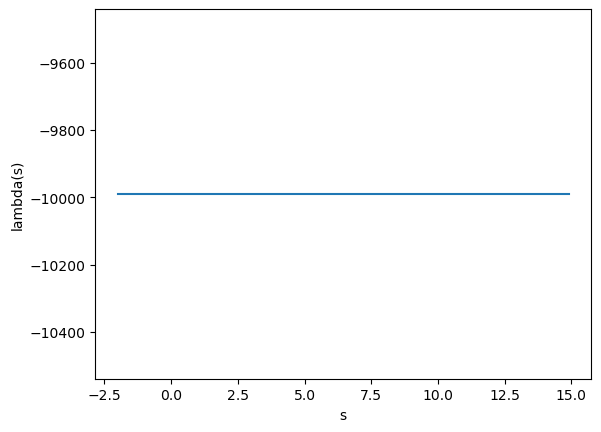

In [34]:
def lambda_s(s, data) :
    return sum( [ -999 for n, s_frac, b_frac in zip(data, s_fracs, b_fracs) ] ) # replace -999 with the correct expression

lambda_values = np.array([ lambda_s(s_value, data) for s_value in s_values ]) # compute the likelihood (the Poisson PDF for each s)

# Plot the result
plt.plot(s_values, lambda_values)
plt.xlabel('s')
plt.ylabel('lambda(s)')

# Find the maximum likelihood value in the list : merge the 2 lists and find the max based on the L value
from operator import itemgetter
print('hat{s}, ML =', min( [ (s,l) for s,l in zip(s_values, lambda_values) ], key=itemgetter(1)))

If all goes well, you should find a best-fit $\hat{s}$ of about 5. We can again compute the exact best-fit value using `minimize_scalar`:

$\mathbf{\color{red}{\rightarrow\text{Use the minimize\_scalar minimization routine to find the precise value of } \hat{s}}}$

In [35]:
from scipy.optimize import minimize_scalar
# ==> Use the minimize_scalar function to find s_hat
#     The syntax is minimize_scalar(func, (min, max)).x  (the .x returns the position of the minimum)
#     and 'func' should be the lambda_s function you defined above
s_hat = -999 # replace with real code

You should find a best-fit value of about $\hat{s} = 5.06$. 

Note than since $L(s)$ was defined only up to a multiplicative factor, $\lambda(s)$ is defined up to an additive constant, so the value $\lambda(\hat{s})$ at the minimum isn't meaningful. On the other hand, the difference between values of $\lambda(s)$ at different $s$ is meaningful, and will be used later in hypothesis testing.